# Return convergence across snapshots — one DreamerV3 hyperparameter sweep

Overlays the learning curves of **several snapshots of the same trial**, so the effect of the
DreamerV3 hyperparameters swept over them can be read off directly. Sibling of
[`sps_train_return_convergence_seeds.ipynb`](sps_train_return_convergence_seeds.ipynb), which
overlays the differently seeded runs of *one* snapshot — here every curve comes from a
different snapshot (its own frozen `code/` + `configs/`), and the training seed is the same
(42) throughout.

As configured, the sources are the twelve
`20260704_183007_sta_lin_battery_only_price_dreamerv3*` snapshots. All twelve carry a
byte-identical `manifest.json` (`git_sha 57c84bf9`, dirty tree), and their
`param_space.json` files — the algorithm config Ray was actually handed, dumped by
`run_train_ray.py` (line 173 in these snapshots' frozen `code/`, line 179 in the repo
today) — differ in exactly four DreamerV3 keys: `batch_size_B`,
`batch_length_T`, `horizon_H` and `training_ratio`. Every other key, `seed = 42` included, is
identical across all of them, which is why the curves below are attributable to those four
knobs.

> **Duplicate pairs — the intended contrast is missing:** the `_lti` suffix was meant to mark
> `training_ratio = 10` against `5` in the un-suffixed snapshot, and `_long_H` a longer
> imagination horizon. Neither edit reached the frozen configs. `v6`, `v6_lti`, `v7` and
> `v7_lti` all declare `training_ratio: 10.0` in their trial YAML *and* record
> `training_ratio = 10.0` in `param_space.json` (written at run start, so it is what Ray
> actually ran); `v2_long_H` carries `horizon_H = 6`, the shortest horizon in the whole sweep,
> the same value as `v2`. The three pairs are in fact identical in everything the snapshots
> record — `diff -r -x __pycache__` over their `code/` trees is empty, their trial YAMLs are
> byte-identical (same md5), Tune's stored `params.json` differs only in Python object
> addresses, both members were launched with the same single `--trial` argument onto the same
> `A100 MIG 1g.5gb` / 3 CPUs, and no referenced data file has been touched since 2026-07-22.
> Their curves therefore measure run-to-run nondeterminism at a fixed seed (`42`), not a
> configuration difference; they are drawn in the same colour, the suffixed one dashed.
> **Consequence for reading the sweep:** it contains no single-knob `training_ratio 5` vs `10`
> comparison. The only pair differing in `training_ratio` alone is `v1` (`r128`) vs `v4` (`r5`),
> both `B16 T64 H15`. Getting the intended comparison needs a rerun of `v6`/`v7` with
> `training_ratio: 5`.

For each snapshot the main RLlib TBX log under `runs/train_*/models/**/events.out.tfevents.*`
is parsed (the `eval_trajectories/` sub-runs live under `ep_metrics/` and are not matched) and
two scalars are extracted:

| Series | Tag |
|---|---|
| training | `ray/tune/env_runners/episode_return_mean` |
| in-training eval | `ray/tune/evaluation/env_runners/episode_return_mean` |

> **Several run directories per snapshot:** re-submitting a snapshot creates a second
> `runs/train_*` directory; some of those never produced a log (they hold only
> `slurm_job_id`). Directories without an event file are skipped, and if more than one carries
> a log the trial directory with the most event bytes wins — with a printed note. Within the
> winning trial directory *all* event files are merged (a step re-logged by a later file wins),
> so a run resumed via `run_train_ray.py --restore` is not silently truncated.

> **Step axis:** the frozen `code/adv_building_gym/ray/training/common_model_config.py` of these
> snapshots contains no `_env_step_axis_on_train_result` hook — that hook, which mirrors
> `num_env_steps_sampled_lifetime` into `timesteps_total` so the TBX writer uses it as
> `global_step`, arrived later (commit `383a3e7`, 2026-07-15). Without it Tune falls back to
> `training_iteration`, so these event files are **iteration-indexed**. The unit is
> nevertheless detected per snapshot by comparing the last logged step against
> `training_iteration` and `num_env_steps_sampled_lifetime` in the last row of the run's
> `progress.csv`; `X_AXIS` converts with that same row's
> `env_runners/num_episodes_lifetime / training_iteration` ratio (the *measured*
> episodes-per-iteration). `progress.csv` is used rather than `result_0.json` because Tune
> writes it while the run is still going — one of the snapshots below is still training.

Parsing an event file is slow, so extracted curves are cached as small CSVs under
`.tb_return_cache/` next to this notebook (shared with the seeds notebook); delete that folder
to force a re-parse.

**Main input:** set `SNAPSHOTS` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose training / in-training-eval return curves are overlaid. Keys per entry:
#   path       snapshot dir (absolute, or relative to the repo root)
#   label      short name shown in the legend and used as the table index
#   color      line colour; snapshots that share a configuration share a colour
#   linestyle  matplotlib linestyle; the secondary encoding that separates same-colour entries
#
# Colours are the validated 8-slot categorical palette (blue, orange, aqua, yellow, magenta,
# green, violet, red), one hue per configuration family.
ALGO_TYPE = "dreamerv3"
SNAPSHOT_PREFIX = "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3"

SNAPSHOTS = [
    {"path": f"{SNAPSHOT_PREFIX}",             "label": "v1 (abort.)",        "color": "#2a78d6", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_lo_tr",       "label": "v1 (compl.)",  "color": "#2a78d6", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v2",          "label": "v2",        "color": "#eb6834", "linestyle": "-"},
    # {"path": f"{SNAPSHOT_PREFIX}_v2_long_H",   "label": "v2_long_H", "color": "#eb6834", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v3_la_ti",    "label": "v3",        "color": "#1baf7a", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v3",          "label": "v3_lti",    "color": "#1baf7a", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v4",          "label": "v4",        "color": "#eda100", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v5",          "label": "v5",        "color": "#e87ba4", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v6",          "label": "v6",        "color": "#008300", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v6_lti",      "label": "v6_lti",    "color": "#008300", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v7",          "label": "v7",        "color": "#4a3aa7", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v7_lti",      "label": "v7_lti",    "color": "#4a3aa7", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v8",          "label": "v8",        "color": "#e34948", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v8_lti",      "label": "v8_lti",    "color": "#e34948", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_default",     "label": "default",   "color": "#6c0063ff", "linestyle": "-"},
]

# A snapshot without any usable training log (e.g. a job still queued) is skipped with a
# warning instead of aborting the notebook. Set False to make it an error.
SKIP_SNAPSHOTS_WITHOUT_LOG = True

# The two RLlib return scalars, plotted as the training / eval series.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"

# The param_space.json keys that differ across these snapshots; shown in the table and, with
# LABEL_WITH_PARAMS, appended to the legend entry. Set to () for a snapshot set that differs
# elsewhere — the values are read straight from each run's own param_space.json.
PARAM_KEYS = ("batch_size_B", "batch_length_T", "horizon_H", "training_ratio")
LABEL_WITH_PARAMS = True

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# The training and eval figures are separate; SHARE_Y puts them on one common y-range so they
# stay comparable side by side in the thesis.
SHARE_Y = True

# Clips the y-axis at this percentile of the drawn values, so a single early collapse (the
# harsh first-iteration returns) does not squash the converged part of every curve.
# Set to None to show the full range.
Y_CLIP_PERCENTILE = None

# x-axis unit: "episodes", "iterations" (the raw TBX step of these snapshots) or
# "env_steps" (millions). The conversion factors are read per snapshot from progress.csv.
X_AXIS = "episodes"
EPISODE_LENGTH = 288  # env_meta.EPISODE_LENGTH of the trial; only used for env-step-indexed logs

# Reference machine speed the corrected runtimes are expressed in, in milliseconds per
# env.step(). Only ratios between snapshots carry meaning, so the value is a free scale; 1.0
# keeps `train_h_norm` close to the wall-clock hours of an uncontended run. See the table
# section below for what the correction does and what it assumes.
REFERENCE_ENV_STEP_MS = 1.0

# Filename prefix for the saved figures.
OUT_PREFIX = f"{ALGO_TYPE}_snapshots_return"

In [2]:
import csv
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"


# The event files of a snapshot's main RLlib TBX log, oldest first, together with the run and
# tune-trial directory they belong to. Re-submitting a snapshot leaves several runs/train_*
# directories, some without any log at all; the tune trial directory holding the most event
# bytes wins. All event files of that directory are returned, because a run resumed via
# --restore keeps writing into it and its curve is spread over several files.
def _snapshot_event_files(snapshot_dir: Path) -> tuple[list[Path], Path, Path] | None:
    candidates = list(snapshot_dir.glob("runs/train_*/models/**/events.out.tfevents.*"))
    if not candidates:
        return None
    by_trial_dir: dict[Path, list[Path]] = {}
    for path in candidates:
        by_trial_dir.setdefault(path.parent, []).append(path)
    trial_dir = max(by_trial_dir, key=lambda directory: sum(p.stat().st_size for p in by_trial_dir[directory]))
    if len(by_trial_dir) > 1:
        others = sorted(str(d.relative_to(snapshot_dir)) for d in by_trial_dir if d != trial_dir)
        print(f"note: {snapshot_dir.name} holds {len(by_trial_dir)} logged trial dirs — "
              f"using the largest, ignoring {others}")
    # runs/train_*/models/... — the run dir is the ancestor directly under runs/.
    run_dir = next(parent for parent in trial_dir.parents if parent.parent.name == "runs")
    return sorted(by_trial_dir[trial_dir], key=lambda path: path.stat().st_mtime), run_dir, trial_dir


# Extracts the requested scalar tags from one snapshot's event files into a long frame
# (tag, step, value), caching the result as a CSV keyed by every input file's
# path + size + mtime (so a resumed / still-running log re-parses).
def _extract_curves(event_files: list[Path], tags: tuple[str, ...]) -> pd.DataFrame:
    fingerprint = "|".join(
        f"{path}:{path.stat().st_size}:{int(path.stat().st_mtime)}" for path in event_files
    ) + "|" + ",".join(sorted(tags))
    cache_path = CACHE_DIR / f"{hashlib.md5(fingerprint.encode()).hexdigest()}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    rows = []
    for file_order, event_file in enumerate(event_files):
        for event in EventFileLoader(str(event_file)).Load():
            for value in event.summary.value:
                if value.tag not in tags:
                    continue
                # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
                scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
                rows.append({"tag": value.tag, "step": event.step, "value": scalar, "file_order": file_order})
    if not rows:
        raise ValueError(f"None of {tags} found in {[str(p) for p in event_files]}")

    curves = (
        pd.DataFrame(rows)
        .sort_values(["tag", "file_order", "step"])
        # Resume overlap: the same step logged again by a later event file wins.
        .drop_duplicates(["tag", "step"], keep="last")
        .sort_values(["tag", "step"])
        .reset_index(drop=True)
    )
    CACHE_DIR.mkdir(exist_ok=True)
    curves.to_csv(cache_path, index=False)
    return curves


# The algorithm-config values Ray was handed, from the run's param_space.json
# (written by run_train_ray.py:179) — the authoritative record of what a snapshot ran with,
# never the directory name.
def _run_params(run_dir: Path, keys: tuple[str, ...]) -> dict:
    param_space_path = run_dir / "param_space.json"
    if not param_space_path.is_file():
        print(f"WARNING: {run_dir.name} has no param_space.json — its hyperparameters are unknown")
        return {key: None for key in (*keys, "seed")}
    param_space = json.loads(param_space_path.read_text())
    return {key: param_space.get(key) for key in (*keys, "seed")}


# The column names one timer's distribution contributes, in table order: the bare prefix is the
# median, the rest carry their statistic as a suffix.
TIMER_PERCENTILES = (5, 10, 25, 75, 90, 95)


def _timer_stat_keys(prefix: str) -> tuple[str, ...]:
    return (prefix, f"{prefix}_mean", f"{prefix}_std", *(f"{prefix}_p{p}" for p in TIMER_PERCENTILES))


# Distribution of one per-iteration timer over a whole run, in milliseconds. A run that held one
# speed throughout has all of these within a few percent of each other; one that changed speed
# part-way has a bimodal series — the mean pulled off the median, a large std, and the low/high
# percentiles sitting in different regimes. A short regime (< 5 % of the iterations) hides from
# the percentiles but still moves mean and std, which is why both are reported.
def _timer_stats(values: list[float], prefix: str) -> dict:
    keys = _timer_stat_keys(prefix)
    series = np.asarray(values, dtype=float)
    if not series.size:
        return dict.fromkeys(keys, float("nan"))
    quantiles = np.percentile(series, [50, *TIMER_PERCENTILES])
    return {
        prefix: float(quantiles[0]),
        f"{prefix}_mean": float(series.mean()),
        # ddof=1 matches pandas' default, so the value reproduces if recomputed from the CSV.
        f"{prefix}_std": float(series.std(ddof=1)) if series.size > 1 else float("nan"),
        **{f"{prefix}_p{p}": float(q) for p, q in zip(TIMER_PERCENTILES, quantiles[1:])},
    }


# Step-axis unit, x-axis conversion factors, elapsed training time and the machine-speed
# correction of that time, all from the tune trial's progress.csv, which Tune appends to every
# iteration — so this also works for a run that is still training (result_0.json only appears
# once the tuner finishes).
#
# `time_total_s` is Tune's own accumulator of `time_this_iter_s`, i.e. wall-clock spent in the
# training iterations; it excludes the driver setup before iteration 1 (Ray init, env build,
# CSV parsing) and, unlike `time_since_restore`, carries over a `--restore` resume.
#
# Wall-clock alone is not a cost measure here: these runs went to different SLURM nodes at
# different times, and a node busy with other tenants stretches every part of an iteration.
# `env_runners/env_step_timer` is therefore used as a machine-speed proxy: an EMA over single
# `self.env.step()` calls (`ray/rllib/env/env_runner.py:253`, ema_coeff 0.01 per
# `ray/rllib/utils/metrics/stats.py:175`) covering the component loops, the pandas row lookups
# of the outer statesources and the numpy work of the wrapper chain — CPU only, with no policy
# forward (timed separately as `rlmodule_inference_timer`) and no GPU. What makes it a usable
# probe is not that it is cheap but that it is configuration-independent: none of batch_size_B /
# batch_length_T / horizon_H / training_ratio reaches env.step(), and the env, wrappers, episode
# length and data schedule are identical across this sweep. Each iteration's wall time is
# rescaled by its own env-step time to REFERENCE_ENV_STEP_MS, giving `train_seconds_normalised`.
# Its distribution over the run (`env_step_ms*`) is the diagnostic for whether a run was slowed
# at all.
#
# `timers/learn` (`ray/rllib/algorithms/dreamerv3/dreamerv3.py:593`) is summarised the same way
# as `learn_ms`, but it is the opposite kind of quantity: the cost of ONE gradient update — again
# an EMA over calls, so it trails a speed change by roughly 100/updates-per-iteration iterations
# — and it scales with batch_size_B, batch_length_T and horizon_H. It is therefore a learner-cost
# diagnostic, NOT a machine probe, and is deliberately not used in the correction.
#
# `learn_iter_ms*` scales it up to the learner time of a whole iteration. The multiplier is the
# iteration's own update count from `num_grad_updates_lifetime`, NOT `training_ratio`: the loop
# at dreamerv3.py:588-591 replays batch_size_B x batch_length_T timesteps per update until
# replayed / sampled >= training_ratio, i.e. ceil(training_ratio * 288 / (B*T)) updates — 12 for
# r=10 at B*T=256, 36 for r=128 at B*T=1024, 2 for r=5 at B*T=1024. `updates_per_iter` reports
# the measured value, which is constant within each of these runs.
def _run_step_scales(trial_dir: Path, last_step: float) -> dict:
    progress_path = trial_dir / "progress.csv"
    if not progress_path.is_file():
        raise FileNotFoundError(f"No progress.csv next to the event file in {trial_dir}")
    columns = ("training_iteration", "num_env_steps_sampled_lifetime", "env_runners/num_episodes_lifetime",
               "time_total_s")
    normalised_seconds = 0.0
    env_step_ms_values, learn_ms_values, learn_iter_ms_values, updates_per_iter_values = [], [], [], []
    with progress_path.open() as handle:
        last_row, previous_updates = None, 0.0
        for row in csv.DictReader(handle):
            # A run still in progress can leave a torn final line; keep the last complete one.
            if all(row.get(column) for column in columns):
                last_row = row
            iteration_seconds, env_step_seconds = row.get("time_this_iter_s"), row.get("env_runners/env_step_timer")
            if iteration_seconds and env_step_seconds and float(env_step_seconds) > 0.0:
                env_step_ms = 1000.0 * float(env_step_seconds)
                env_step_ms_values.append(env_step_ms)
                normalised_seconds += float(iteration_seconds) * REFERENCE_ENV_STEP_MS / env_step_ms
            # Iterations before the replay buffer holds a full batch report no learner time.
            learn_seconds, updates_lifetime = row.get("timers/learn"), row.get("num_grad_updates_lifetime")
            updates_this_iter = float(updates_lifetime) - previous_updates if updates_lifetime else 0.0
            if learn_seconds and float(learn_seconds) > 0.0:
                learn_ms = 1000.0 * float(learn_seconds)
                learn_ms_values.append(learn_ms)
                if updates_this_iter > 0.0:
                    updates_per_iter_values.append(updates_this_iter)
                    learn_iter_ms_values.append(learn_ms * updates_this_iter)
            if updates_lifetime:
                previous_updates = float(updates_lifetime)
    if last_row is None:
        raise ValueError(f"No complete row in {progress_path}")
    iterations = float(last_row["training_iteration"])
    env_steps = float(last_row["num_env_steps_sampled_lifetime"])
    episodes = float(last_row["env_runners/num_episodes_lifetime"])
    train_seconds = float(last_row["time_total_s"])
    # An algorithm that does not log the env-step timer leaves the correction undefined; the
    # raw wall-clock columns stay usable and the normalised ones show NaN.
    machine = {
        **_timer_stats(env_step_ms_values, "env_step_ms"),
        **_timer_stats(learn_ms_values, "learn_ms"),
        "updates_per_iter": float(np.median(updates_per_iter_values)) if updates_per_iter_values else float("nan"),
        **_timer_stats(learn_iter_ms_values, "learn_iter_ms"),
        "train_seconds_normalised": normalised_seconds if env_step_ms_values else float("nan"),
    }
    # Iteration-indexed vs env-step-indexed logs differ by ~3 orders of magnitude, so the
    # last logged step identifies the unit unambiguously.
    if abs(last_step - iterations) <= abs(last_step - env_steps):
        return {
            "step_unit": "iteration",
            "episodes_per_step": episodes / iterations,
            "env_steps_per_step": env_steps / iterations,
            "train_seconds": train_seconds,
            **machine,
        }
    return {"step_unit": "env_step", "episodes_per_step": 1.0 / EPISODE_LENGTH, "env_steps_per_step": 1.0,
            "train_seconds": train_seconds, **machine}


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float) -> np.ndarray:
    if weight <= 0.0:
        return np.asarray(values, dtype=float)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return np.asarray(smoothed, dtype=float)


labels = [snapshot["label"] for snapshot in SNAPSHOTS]
if len(labels) != len(set(labels)):
    raise ValueError(f"Every snapshot needs a unique 'label'; got {labels}")
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/.tb_return_cache


## Output naming

Everything saved here lands next to the notebook as
`<prefix>_<date>_<time>_out_<i>.<file format>`: one timestamp per notebook run, `out_index`
counting up per saved artefact, so no run overwrites an earlier one.

In [3]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    stem = f"{OUT_PREFIX}_{OUT_RUN_STAMP}_out_{out_index}"
    return OUT_DIR / f"{stem}.{file_format}"

## Load the per-snapshot curves

One record per snapshot: the run directory that actually produced a log, the number of merged
event files, the DreamerV3 hyperparameters Ray ran with (from `param_space.json`), the training
and eval curves, and the step-axis scales. The table lists how far each snapshot got, how long
it took and where its returns ended up — `final_*` is the last **smoothed** value (`SMOOTHING`),
which is what the plots below show, while `max_eval` is the raw best in-training eval return.

`train_hours` is the wall-clock training time of the run, read from the same last complete row
of `progress.csv` as the step scales: Tune's `time_total_s`, the accumulated `time_this_iter_s`
over all iterations (`ray/tune/trainable/trainable.py:344-348` of the installed Ray). It is
therefore time spent inside the training iterations — the driver setup before iteration 1 (Ray
init, env construction, CSV parsing) is not in it — and it survives a `--restore` resume, since
Tune reloads the accumulator from the checkpoint (`trainable.py:539`) while `time_since_restore`
starts over. For a run that is still training it is the time reached so far. Because the runs
here got different distances (see `episodes`), `h_per_1k_eps` divides it by the episodes
reached: hours per 1000 training episodes.

> **Wall-clock is not a cost comparison — use the `_norm` columns.** These jobs went to
> different SLURM nodes at different times, sharing each node (4 CPUs and a `1g.5gb` MIG slice
> per job) with whatever else was running, and a busy node stretches every part of an
> iteration. The runs show it directly: `v7_lti` crosses a contention boundary at iteration
> 5710, where the node-wide `perf/cpu_util_percent` in its `progress.csv`
> (`psutil.cpu_percent()`, `ray/tune/utils/util.py:80`) drops from ~45 % to ~3 %. At completely
> unchanged configuration its own `env_runners/env_step_timer` then halves (1.92 → 1.03 ms), a
> normal iteration goes 5.15 s → 2.79 s and an eval iteration 38.9 s → 21.5 s. `train_h_norm`
> and `h_per_1k_eps_norm` therefore rescale **each** iteration's wall time by **that**
> iteration's own env-step cost to `REFERENCE_ENV_STEP_MS`; `env_step_ms` is the run's median
> env-step cost, i.e. how slow its machine was.
>
> *Why that timer is a valid probe.* `env.step()` here is not one cheap numpy call — it runs
> the infra / statesource loops, `self.ts.iloc[...]` row lookups in the outer statesources
> (`weather.py:123`, `energy_price.py:148`, `date_source.py:63`) and the `HistoryWrapper` /
> `ForecastWrapper` / flatten chain, and because RLlib vectorises with gymnasium's default
> NEXT_STEP autoreset (`single_agent_env_runner.py:707`, `sync_vector_env.py:251`) one call in
> every 288 performs the episode reset instead of a step, CSV reload included. What licenses it
> as a probe is not that it is simple but that it is **configuration-independent**: it is
> CPU-only (the policy forward is timed separately as `rlmodule_inference_timer`, and no GPU is
> involved), none of `batch_size_B` / `batch_length_T` / `horizon_H` / `training_ratio` reaches
> it, and the env, wrappers, episode length and data schedule are identical across this sweep.
> The autoreset does not leak into the reported value measurably either: grouped by
> `training_iteration % 5` — the CSV-reload cadence of `configs/schedules/data/train.yaml` —
> the values spread by 0.07 % (`v7`) and 0.14 % (`v7_lti`), the episode-start spike having
> decayed out of the EMA (`ema_coeff` 0.01, `ray/rllib/utils/metrics/stats.py:175`) long before
> the iteration reports.
>
> *Validation:* the runs that cross a contention boundary give the same normalised cost on both
> sides — residuals of −0.8 % / +1.4 % (`v6` normal / eval iterations), +1.9 % / +3.7 %
> (`v7_lti`) and +4.5 % / +2.1 % (`v8_lti`) — and the component timers scale together across
> `v7_lti`'s boundary (env step ×0.54, learner call ×0.57, sample ×0.52), i.e. the whole process
> is slowed, not just the env. *Limits:* the proxy is calibrated only within runs on one node,
> so read the corrected hours as ±5-10 %; comparing across nodes additionally assumes their
> single-thread speed is captured by `env.step()`, which nothing in these logs can confirm.
>
> *What it changes here:* `v7` (`r10`, 84 000 gradient updates in `num_grad_updates_lifetime`)
> reads 13.27 h against `v7_lti` (`r5`, 42 000 updates) at 15.21 h — the run doing twice the
> learner work looks cheaper, because `v7_lti` spent 82 % of its iterations at 1.94 ms per env
> step against `v7`'s 1.21 ms. Corrected: 11.15 h vs 8.57 h, and every `r10` / `r5` pair of the
> sweep then orders the way the knob predicts. Note also that neither number is dominated by
> the learner: with `evaluation_interval = 10` and `evaluation_duration = 10` episodes, each
> eval round samples 2880 env steps against the 288 of a training iteration and runs no
> gradient update at all, taking 33-46 % of the total wall clock of these runs.

Snapshots whose runs never produced an event file are reported and dropped (a job that is still
queued leaves a `runs/` directory holding only its `slurm_job_id`).

In [4]:
records = []
for snapshot in SNAPSHOTS:
    snapshot_dir = Path(snapshot["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    located = _snapshot_event_files(snapshot_dir)
    if located is None:
        message = f"{snapshot['label']}: no training TBX event file under {snapshot_dir.name}/runs/train_*/models"
        if not SKIP_SNAPSHOTS_WITHOUT_LOG:
            raise FileNotFoundError(message)
        print(f"WARNING: {message} — snapshot skipped")
        continue
    event_files, run_dir, trial_dir = located

    curves = _extract_curves(event_files, (TRAIN_METRIC, EVAL_METRIC))
    series = {
        name: curves.loc[curves["tag"] == tag, ["step", "value"]].reset_index(drop=True)
        for name, tag in (("train", TRAIN_METRIC), ("eval", EVAL_METRIC))
    }
    missing = [name for name, frame in series.items() if frame.empty]
    if missing:
        raise ValueError(f"{snapshot['label']}: no points for {missing} — check the metric tags")

    records.append({
        **snapshot,
        "snapshot": snapshot_dir.name,
        "run": run_dir.name,
        "event_files": len(event_files),
        "params": _run_params(run_dir, PARAM_KEYS),
        "curves": series,
        "scales": _run_step_scales(trial_dir, float(series["train"]["step"].iloc[-1])),
    })

if not records:
    raise FileNotFoundError("None of the configured snapshots holds a training log")

# Compact legend spelling of the swept keys; a key without an entry keeps its full name.
PARAM_SHORT_NAMES = {"batch_size_B": "B", "batch_length_T": "T", "horizon_H": "H", "training_ratio": "r"}


def _parameter_text(params: dict) -> str:
    parts = []
    for key in PARAM_KEYS:
        value = params[key]
        formatted = f"{value:g}" if isinstance(value, (int, float)) else "?"
        parts.append(f"{PARAM_SHORT_NAMES.get(key, key)}{formatted}")
    return " ".join(parts)


for record in records:
    for name in ("train", "eval"):
        record[f"smoothed_{name}"] = _tb_smooth(record["curves"][name]["value"].to_numpy(), SMOOTHING)
    record["legend"] = (f"{record['label']}  ({_parameter_text(record['params'])})"
                        if LABEL_WITH_PARAMS else record["label"])

seeds = {record["params"]["seed"] for record in records}
step_units = {record["scales"]["step_unit"] for record in records}
print(f"\nStep unit: {sorted(step_units)}  ({X_AXIS} on the x-axis) | seeds: {sorted(seeds, key=str)}")


# One table row per snapshot. `train_hours` is the run's raw wall-clock training time (Tune's
# time_total_s) and `h_per_1k_eps` divides it by the episodes reached, so a run that stopped
# early is still comparable in cost per unit of experience. Both are node-dependent: the
# `_norm` columns repeat them with the machine-speed correction applied (see _run_step_scales)
# and are the ones to compare across snapshots that ran at different times or on different
# nodes.
#
# Three timer distributions follow (median / mean / std / p5 / p10 / p25 / p75 / p90 / p95, ms):
#   env_step_ms*    the machine-speed probe the correction divides by — one env.step(). Identical
#                   work in every snapshot here, so its spread is contention, not configuration.
#   learn_ms*       one gradient update. Configuration-dependent by design (B / T / H), so compare
#                   it only between snapshots sharing those; within a run its spread is the same
#                   contention the env probe sees.
#   learn_iter_ms*  the same, multiplied by `updates_per_iter` — the learner time of a whole
#                   iteration, which is the quantity `training_ratio` is meant to buy.
PROBE_KEYS = (_timer_stat_keys("env_step_ms") + _timer_stat_keys("learn_ms")
              + ("updates_per_iter",) + _timer_stat_keys("learn_iter_ms"))


def _summary_row(record: dict) -> dict:
    last_step = float(record["curves"]["train"]["step"].iloc[-1])
    episodes = int(last_step * record["scales"]["episodes_per_step"])
    train_hours = record["scales"]["train_seconds"] / 3600.0
    train_hours_normalised = record["scales"]["train_seconds_normalised"] / 3600.0
    return {
        "label": record["label"],
        "snapshot_suffix": record["snapshot"].replace("20260704_183007_sta_lin_battery_only_price_", ""),
        "run": record["run"],
        "event_files": record["event_files"],
        **{key: record["params"][key] for key in PARAM_KEYS},
        "last_step": int(last_step),
        "episodes": episodes,
        "train_points": len(record["curves"]["train"]),
        "eval_points": len(record["curves"]["eval"]),
        **{key: round(record["scales"][key], 3) for key in PROBE_KEYS},
        "train_hours": round(train_hours, 2),
        "train_h_norm": round(train_hours_normalised, 2),
        "h_per_1k_eps": round(1000.0 * train_hours / episodes, 3) if episodes else float("nan"),
        "h_per_1k_eps_norm": round(1000.0 * train_hours_normalised / episodes, 3) if episodes else float("nan"),
        "final_train": round(float(record["smoothed_train"][-1]), 3),
        "final_eval": round(float(record["smoothed_eval"][-1]), 3),
        "max_eval": round(float(record["curves"]["eval"]["value"].max()), 3),
    }


summary = pd.DataFrame([_summary_row(record) for record in records]).set_index("label")
# summary_table_out_path_tex = next_out_path("tex")
# summary.to_latex(summary_table_out_path_tex)
summary_table_out_path_csv = next_out_path("csv")
summary.to_csv(summary_table_out_path_csv)
summary

note: 20260704_183007_sta_lin_battery_only_price_dreamerv3 holds 5 logged trial dirs — using the largest, ignoring ['runs/train_20260810_112805_cseed42/models/sta_lin_battery_only_price/ray/dreamerv3/dreamerv3_seed42_20260810_113103/3477c_sta_lin_battery_only_price', 'runs/train_20260810_112806_cseed46/models/sta_lin_battery_only_price/ray/dreamerv3/dreamerv3_seed42_20260810_113103/3477d_sta_lin_battery_only_price', 'runs/train_20260810_112807_cseed71/models/sta_lin_battery_only_price/ray/dreamerv3/dreamerv3_seed42_20260810_113103/3477d_sta_lin_battery_only_price', 'runs/train_20260810_112807_cseed97/models/sta_lin_battery_only_price/ray/dreamerv3/dreamerv3_seed42_20260811_053105/15af1_sta_lin_battery_only_price']

Step unit: ['iteration']  (episodes on the x-axis) | seeds: [141, 42]


,snapshot_suffix,run,event_files,batch_size_B,batch_length_T,horizon_H,training_ratio,last_step,episodes,train_points,...,learn_iter_ms_p75,learn_iter_ms_p90,learn_iter_ms_p95,train_hours,train_h_norm,h_per_1k_eps,h_per_1k_eps_norm,final_train,final_eval,max_eval
label,,,,,,,,,,,,,,,,,,,,,
v1 (abort.),dreamerv3,train_20260810_112808_cseed141,1,16,64,15,128.0,3371,3374,3371,...,16090.073,16143.957,16172.582,17.93,17.56,5.313,5.203,12.159,12.788,14.625
v1 (compl.),dreamerv3_lo_tr,train_20260805_113706,1,16,64,15,128.0,6769,6771,6769,...,15928.501,15983.880,16023.179,35.89,34.99,5.301,5.168,12.897,13.545,16.381
v2,dreamerv3_v2,train_20260801_164022,1,64,16,6,5.0,6997,7000,6997,...,553.943,559.445,562.502,14.29,6.82,2.042,0.975,4.733,6.770,12.570
v3,dreamerv3_v3_la_ti,train_20260805_114342,1,8,16,128,10.0,7000,7000,7000,...,13401.038,13437.159,13458.184,32.29,31.34,4.613,4.477,11.778,12.958,15.568
v3_lti,dreamerv3_v3,train_20260801_170619,1,8,16,128,5.0,7000,7000,7000,...,7304.026,7802.118,7881.111,20.56,19.18,2.937,2.739,12.060,13.505,16.474
v4,dreamerv3_v4,train_20260801_170630,1,16,64,15,5.0,6997,7000,6997,...,1146.054,1223.809,1252.337,10.89,7.83,1.555,1.118,7.097,8.907,11.304
v5,dreamerv3_v5,train_20260801_170637,1,4,256,15,5.0,6997,7000,6997,...,2736.643,2777.635,2784.451,12.30,10.87,1.757,1.553,7.897,9.640,11.957
v6,dreamerv3_v6,train_20260803_100725,1,16,16,15,10.0,7000,7000,7000,...,3968.564,4058.173,4101.977,20.35,9.78,2.907,1.398,8.256,9.767,12.437
v6_lti,dreamerv3_v6_lti,train_20260804_162244,1,16,16,15,5.0,7000,7000,7000,...,1001.969,1011.308,1015.670,8.51,8.03,1.215,1.147,8.401,10.232,12.451


## Per-snapshot curves

One line per snapshot, in **two standalone figures** — the training return and the in-training
eval return, each saved as its own `<prefix>_<date>_<time>_out_<i>.pdf` next to this notebook
and carrying **no title** (thesis-ready), so the series is named by the y-axis label. With
`SHARE_Y` both figures use one common y-range, keeping them comparable the way shared panels
would be. Curves are smoothed with TensorBoard's debiased EWMA (`SMOOTHING`); the raw curve is
drawn faint behind each smoothed line while `SHOW_RAW` is set. The eval series is stepwise
because RLlib carries the last eval result forward between eval rounds
(`common.evaluation.interval = 10` iterations in this trial).

The y-range is clipped at the `Y_CLIP_PERCENTILE`-th percentile of everything drawn: the first
iterations sit far below the converged level, and without the clip they compress the part of the
plot that carries the comparison. Where that automatic range is not what the figure needs,
`plot_per_snapshot(series, y_min=…, y_max=…)` pins either end per call — each argument is
independent, and the one left at `None` keeps its automatic bound; pass the same values to both
calls to keep the two figures on one scale. Legend entries carry the four swept hyperparameters,
so the figure is readable without the table above; same-colour pairs are the identically
configured snapshots, the dashed one being the `_lti` / `_long_H` twin.

As configured, the sweep separates into three groups that stay apart for the whole run rather
than converging: `v3` (`B8 T16 H128 r5`) and the `v7` pair (`B16 T16 H30 r10`) climb to a
smoothed training return of 11.5-12.1 and an eval return of 12.9-13.5; `v1`, the snapshot's
original run (`r128`), tracks them on the training side (11.58) but sits ~1.4 below them on eval
(10.18) and stops at 3969 episodes; everything else plateaus between 4.7 and 8.5 (training) /
6.8 and 9.8 (eval), with the two `H6` runs (`v2`, `v2_long_H`) last by a clear margin. Holding
`B16 T16 r10` fixed and varying only the imagination horizon gives `H15` → 9.77, `H30` → 12.90
eval; `H60` (`v8`) is still training and cannot be read yet.

In [5]:
sns.set_theme(style="whitegrid", context="notebook")

SERIES_LABELS = {"train": "Training return", "eval": "In-training eval return"}
# Each series gets its own standalone figure, so the y-label carries the series identity
# (the figures are untitled for the thesis).
Y_LABELS = {
    "train": "Training episode_return_mean",
    "eval": "In-training eval episode_return_mean",
}
TRAIN_COLOR = "#0d54c4"  # strong blue
EVAL_COLOR = "#e2660a"   # strong orange


# x values of one curve in the unit X_AXIS selects, using the snapshot's own step scales.
def _x_values(record: dict, curve: pd.DataFrame) -> tuple[np.ndarray, str]:
    steps = curve["step"].to_numpy(dtype=float)
    scales = record["scales"]
    if X_AXIS == "episodes":
        return steps * scales["episodes_per_step"], "Training episodes"
    if X_AXIS == "iterations":
        if scales["step_unit"] != "iteration":
            return steps / scales["env_steps_per_step"], "Training iterations"
        return steps, "Training iterations"
    if X_AXIS == "env_steps":
        return steps * scales["env_steps_per_step"] / 1e6, "Environment steps (millions)"
    raise ValueError(f"X_AXIS must be 'episodes', 'iterations' or 'env_steps', got {X_AXIS!r}")


# Common y-limits over both series and every snapshot, computed from whatever is actually drawn
# (raw curves dominate the range when SHOW_RAW). Keeps the two standalone figures on the same
# scale, which separate figures otherwise lose; Y_CLIP_PERCENTILE cuts the early collapse.
def _shared_ylim(padding: float = 0.05) -> tuple[float, float] | None:
    if not SHARE_Y:
        return None
    drawn = np.concatenate([
        record["curves"][name]["value"].to_numpy() if SHOW_RAW else record[f"smoothed_{name}"]
        for record in records for name in ("train", "eval")
    ])
    lowest = float(np.percentile(drawn, Y_CLIP_PERCENTILE)) if Y_CLIP_PERCENTILE else float(drawn.min())
    highest = float(drawn.max())
    margin = padding * (highest - lowest)
    return lowest - margin, highest + margin


SHARED_YLIM = _shared_ylim()


# One standalone figure for `series_name` ("train" or "eval"), one line per snapshot.
# `y_min` / `y_max` fix the y-axis of this figure; each is independent, and whichever is left
# None keeps the automatic bound (the SHARE_Y range if SHARE_Y, matplotlib's autoscale
# otherwise). Passing them overrides SHARE_Y / Y_CLIP_PERCENTILE for that bound, so the two
# figures only stay comparable if both calls get the same value.
def plot_per_snapshot(series_name: str, y_min: float | None = None, y_max: float | None = None) -> None:
    fig, ax = plt.subplots(figsize=(9.0, 6.5))
    x_label = ""
    for record in records:
        curve = record["curves"][series_name]
        x_values, x_label = _x_values(record, curve)
        if SHOW_RAW:
            ax.plot(x_values, curve["value"], color=record["color"], alpha=0.15, linewidth=0.4,
                    linestyle=record["linestyle"], zorder=1)
        ax.plot(x_values, record[f"smoothed_{series_name}"], color=record["color"], linewidth=1.3,
                linestyle=record["linestyle"], label=record["legend"], zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(Y_LABELS[series_name])
    ax.margins(x=0.01)
    lower, upper = SHARED_YLIM if SHARED_YLIM is not None else (None, None)
    lower = lower if y_min is None else y_min
    upper = upper if y_max is None else y_max
    if lower is not None or upper is not None:
        # bottom/top keyword: a None side keeps matplotlib's autoscaled bound.
        ax.set_ylim(bottom=lower, top=upper)
    # A dozen curves fill the axes, so the legend sits below them instead of over the data.
    legend = ax.legend(title="", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13),
                       handlelength=2.2, ncol=3, fontsize=8, columnspacing=1.6)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({SERIES_LABELS[series_name]})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_return_20260812_141958_out_2.pdf  (Training return)


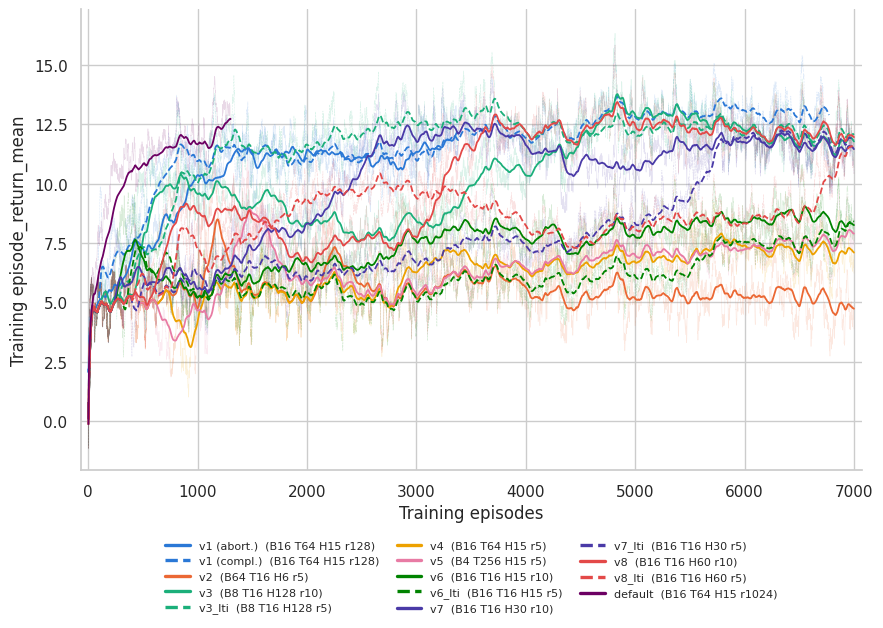

In [6]:
# y_min / y_max pin the y-axis of this figure; drop either to keep the automatic bound.
plot_per_snapshot("train", y_min=None, y_max=None)

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_return_20260812_141958_out_3.pdf  (In-training eval return)


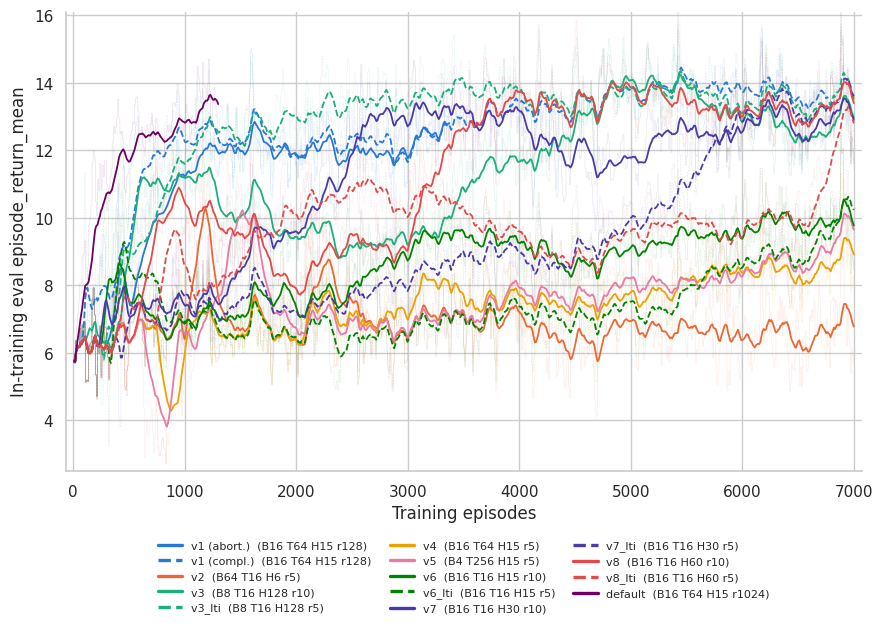

In [7]:
# Give this call the same y_min / y_max as the training figure to keep the two comparable.
plot_per_snapshot("eval", y_min=2.5, y_max=16.1)

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_return_20260812_141958_out_4.pdf  (In-training eval return)


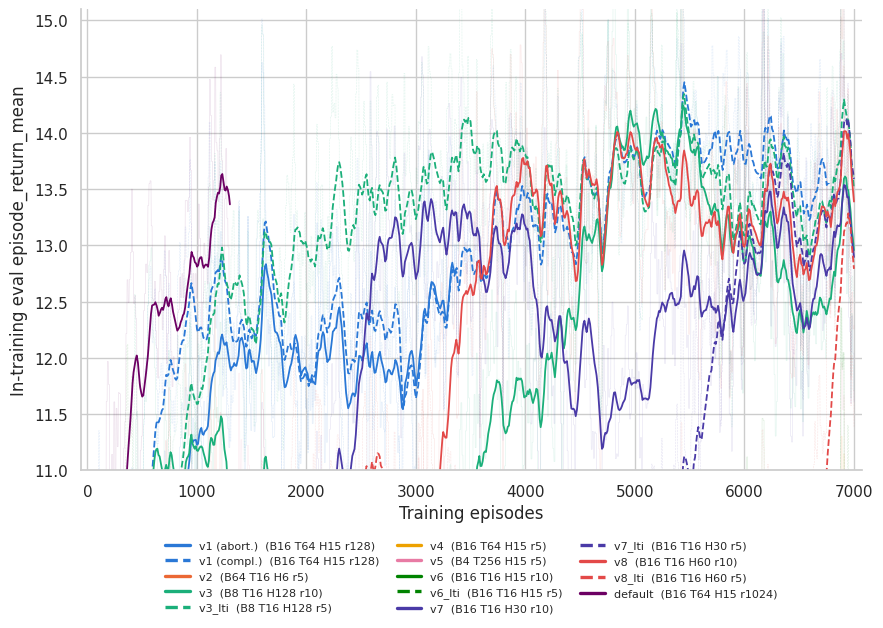

In [8]:
plot_per_snapshot("eval", y_min=11, y_max=15.1)

## Converged return per snapshot

The curve figures answer *how* each configuration got there; this one answers *where it ended
up*. Per snapshot the last smoothed training and eval return (the `final_train` / `final_eval`
columns of the table) are drawn as a connected pair, sorted by the eval value, with the swept
hyperparameters on the tick label and both numbers written out — no reading values off a grid,
and the pairs that share a colour above sit next to each other here.

Snapshots that stopped early (a still-running job, or one that hit the early-stopping criterion)
are marked with `*` after their label and are **not** comparable at face value: their last point
is simply an earlier point in training. The `episodes` column of the table above is the number
to check.

The eval marker sits to the right of the training one for every snapshot except `v1`, i.e. the
held-out data scores *higher* than the training data, by 1.4-2.2 return units. That is a property
of the datasets, not of the policies: the eval EnvRunners run with `eval_mode=True`
(`common_model_config.py:250` in the frozen code), which routes them to the trial's
`data_schedule.eval` combinator — years 2025/2026 against the training years 2024 — and draws a
fresh random (variant, day) per episode. `v1` inverts the gap (train 11.58, eval 10.18) and is
also the only run with `training_ratio = 128`.

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_return_20260812_141958_out_5.pdf
* did not reach 95 % of the longest run's 7000 episodes


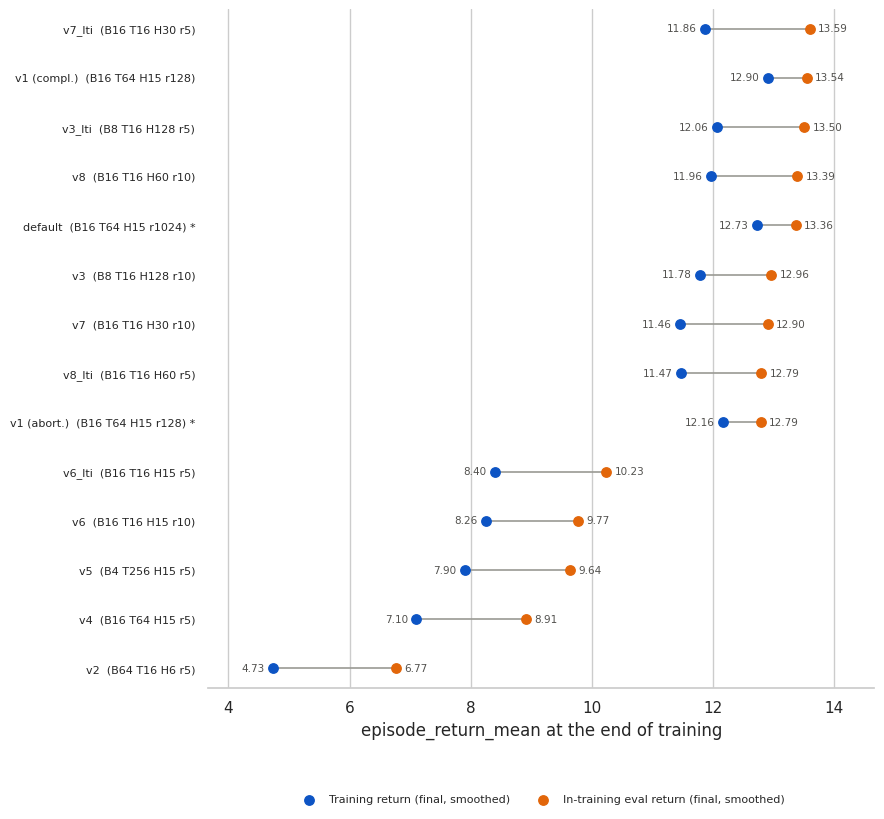

In [9]:
# Snapshots within this fraction of the longest run count as "ran to completion"; the rest are
# marked, because their final return is read at an earlier point in training.
COMPLETE_FRACTION = 0.95


def plot_final_returns() -> None:
    episodes = {record["label"]: float(record["curves"]["train"]["step"].iloc[-1]) * record["scales"]["episodes_per_step"]
                for record in records}
    longest = max(episodes.values())

    rows = sorted(
        ({
            "label": record["label"],
            "legend": record["legend"],
            "train": float(record["smoothed_train"][-1]),
            "eval": float(record["smoothed_eval"][-1]),
            "short": episodes[record["label"]] < COMPLETE_FRACTION * longest,
        } for record in records),
        key=lambda row: row["eval"],
    )

    fig, ax = plt.subplots(figsize=(9.0, 0.45 * len(rows) + 2.0))
    positions = np.arange(len(rows))
    for position, row in zip(positions, rows):
        ax.plot([row["train"], row["eval"]], [position, position], color="#9a9a94", linewidth=1.2, zorder=1)
    ax.scatter([row["train"] for row in rows], positions, s=46, color=TRAIN_COLOR,
               label="Training return (final, smoothed)", zorder=2)
    ax.scatter([row["eval"] for row in rows], positions, s=46, color=EVAL_COLOR,
               label="In-training eval return (final, smoothed)", zorder=2)

    # Each value is written on the outer side of its own marker, so the two labels of a pair
    # never collide however wide or narrow the pair is.
    for position, row in zip(positions, rows):
        outer_left, outer_right = sorted(("train", "eval"), key=lambda key: row[key])
        for key, x_offset, alignment in ((outer_left, -6, "right"), (outer_right, 6, "left")):
            ax.annotate(f"{row[key]:.2f}", (row[key], position), xytext=(x_offset, 0),
                        textcoords="offset points", ha=alignment, va="center",
                        fontsize=7.5, color="#52514e")

    ax.set_yticks(positions)
    ax.set_yticklabels([f"{row['legend']}{' *' if row['short'] else ''}" for row in rows], fontsize=8)
    ax.set_xlabel("episode_return_mean at the end of training")
    ax.set_ylabel("")
    ax.margins(x=0.12, y=0.03)
    ax.grid(axis="y", visible=False)
    # Below the axes, like the curve figures — a legend inside would sit on the markers as soon
    # as the ordering puts a long pair on the right.
    ax.legend(title="", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.10 - 0.6 / len(rows)),
              ncol=2, fontsize=8)
    sns.despine(ax=ax, left=True)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    if any(row["short"] for row in rows):
        print("* did not reach {:.0f} % of the longest run's {:.0f} episodes".format(100 * COMPLETE_FRACTION, longest))
    plt.show()


plot_final_returns()

## Spread of the converged return across the sweep

`mean` / `std` / `min` / `max` over the per-snapshot end-of-training values — the counterpart of
the seed-spread table in [`sps_train_return_convergence_seeds.ipynb`](sps_train_return_convergence_seeds.ipynb),
but here the variation is the hyperparameter sweep, not seed noise. Read the two together: a
sweep spread smaller than the seed spread of that notebook means the knobs did not move the
result beyond what re-seeding alone does.

The identically configured pairs (`v2`/`v2_long_H`, `v6`/`v6_lti`, `v7`/`v7_lti` — see the
intro: the difference their names promise never reached the frozen configs) are quoted separately
below as a nondeterminism floor. The gap inside a pair is what a rerun of the *same*
configuration and seed produces, so a difference between configurations only counts once it
exceeds it.

As configured, the sweep spans far more than that floor: final training return 8.67 ± 2.67
(4.73-12.06) and final eval return 10.08 ± 2.28 (6.77-13.51) across the eleven logged snapshots,
against pair gaps of 0.02 / 0.65 / 0.00 on the eval side. (`v8` is still training, so its row —
and with it the mean and std quoted here — advances a little on every re-run of this notebook.) The pairs are genuinely independent
runs — their per-iteration `env_runners/episode_return_mean` in `progress.csv` already differs at
iteration 1 — so `v7` and `v7_lti` landing on the same 12.90 is convergence to the same level,
not duplicated data. Read together: differences above ~0.7 return units are attributable to the
hyperparameters, and the `v3` / `v7` group clears that by several units.

In [10]:
spread = summary[["final_train", "final_eval", "max_eval"]].agg(["mean", "std", "min", "max"]).round(3)
display(spread)

DUPLICATE_PAIRS = [("v2", "v2_long_H"), ("v6", "v6_lti"), ("v7", "v7_lti"), ("v8", "v8_lti")]
pair_rows = []
for first, second in DUPLICATE_PAIRS:
    if first not in summary.index or second not in summary.index:
        continue
    pair_rows.append({
        "pair": f"{first} vs {second}",
        "d_final_train": round(float(summary.loc[second, "final_train"] - summary.loc[first, "final_train"]), 3),
        "d_final_eval": round(float(summary.loc[second, "final_eval"] - summary.loc[first, "final_eval"]), 3),
        "d_max_eval": round(float(summary.loc[second, "max_eval"] - summary.loc[first, "max_eval"]), 3),
    })
pd.DataFrame(pair_rows).set_index("pair") if pair_rows else "no duplicate pair present in this run"

,final_train,final_eval,max_eval
mean,10.340,11.725,14.337
std,2.543,2.210,1.807
min,4.733,6.770,11.304
max,12.897,13.591,16.474


,d_final_train,d_final_eval,d_max_eval
pair,,,
v6 vs v6_lti,0.145,0.465,0.014
v7 vs v7_lti,0.400,0.694,0.908
v8 vs v8_lti,-0.495,-0.599,-0.812
